# cheias.pt — Data Audit

Every dataset we have, properly aligned, on the same CRS.
**No presentation code.** Just: what do we have, what does it look like, does it align?

In [1]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd, rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

ROOT = Path('.').resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
ASSETS, DATA = ROOT / 'assets', ROOT / 'data'
WEST, SOUTH, EAST, NORTH = -9.6, 36.9, -6.1, 42.2

SM_CMAP = LinearSegmentedColormap.from_list('sm', [
    (0.0,'#8B6914'),(0.25,'#B8860B'),(0.45,'#7A9A6E'),
    (0.6,'#4A90A4'),(0.8,'#2E86AB'),(1.0,'#1B4965')])
PRECIP_BOUNDS = [0,1,5,15,30,50,80,150]
PRECIP_COLORS = ['#f0f0f0','#FFF9C4','#FFD54F','#FF8F00','#E53935','#B71C1C','#4A0000']
PRECIP_CMAP = ListedColormap(PRECIP_COLORS)
PRECIP_CMAP.set_over(PRECIP_COLORS[-1])
PRECIP_NORM = BoundaryNorm(PRECIP_BOUNDS, PRECIP_CMAP.N)


## 1. Portugal Boundaries

In [2]:
districts = gpd.read_file(ASSETS / 'districts.geojson')
print(f'CRS: {districts.crs}  |  Features: {len(districts)}  |  Bounds: {districts.total_bounds}')
districts.head()


CRS: EPSG:4326  |  Features: 18  |  Bounds: [-9.4974666  36.98676179 -6.20594722 42.15362966]


,district,hasc,ipma_code,idDistrito,geometry
0,Évora,PT.EV,EVR,7,"POLYGON ((-7.22588 38.76613, -7.24252 38.84339..."
1,Portalegre,PT.PA,PTG,12,"POLYGON ((-7.22588 38.76613, -7.05608 38.85515..."
2,Viana do Castelo,PT.VC,VCT,16,"POLYGON ((-8.22236 42.15363, -8.62688 42.05103..."
3,Castelo Branco,PT.CB,CBO,5,"POLYGON ((-6.9421 40.25498, -7.11026 40.3193, ..."
4,Guarda,PT.GU,GDA,9,"POLYGON ((-6.87451 40.27919, -6.79444 40.3564,..."


## 2. Soil Moisture COGs

In [3]:
sm_cogs = sorted((DATA / 'cog' / 'soil-moisture').glob('*.tif'))
print(f'Count: {len(sm_cogs)}, range: {sm_cogs[0].stem} to {sm_cogs[-1].stem}')
with rasterio.open(sm_cogs[0]) as ds:
    print(f'CRS: {ds.crs} | Size: {ds.width}x{ds.height} | Pixel: {ds.res[0]:.4f} deg = {ds.res[0]*111:.1f}km')
with rasterio.open(DATA / 'cog' / 'soil-moisture' / '2026-01-28.tif') as ds:
    sm_jan28 = ds.read(1)
    sm_extent = [ds.bounds.left, ds.bounds.right, ds.bounds.bottom, ds.bounds.top]
    v = sm_jan28[~np.isnan(sm_jan28)]
    print(f'Jan 28: min={v.min():.4f} max={v.max():.4f} mean={v.mean():.4f} negatives={int((v<0).sum())}')


Count: 77, range: 2025-12-01 to 2026-02-15
CRS: EPSG:4326 | Size: 175x265 | Pixel: 0.0200 deg = 2.2km
Jan 28: min=-0.0353 max=0.5348 mean=0.4076 negatives=7


## 3. Precipitation COGs

In [4]:
pr_cogs = sorted((DATA / 'cog' / 'precipitation').glob('*.tif'))
print(f'Count: {len(pr_cogs)}')
for d in ['2026-01-29','2026-02-06','2026-02-10']:
    with rasterio.open(DATA / 'cog' / 'precipitation' / f'{d}.tif') as ds:
        data = ds.read(1); v = data[~np.isnan(data)]
        print(f'  {d}: min={v.min():.1f} max={v.max():.1f} mean={v.mean():.1f} mm/day')
with rasterio.open(DATA / 'cog' / 'precipitation' / '2026-01-29.tif') as ds:
    pr_kristin = ds.read(1)
    pr_extent = [ds.bounds.left, ds.bounds.right, ds.bounds.bottom, ds.bounds.top]


Count: 77
  2026-01-29: min=0.8 max=74.9 mean=21.8 mm/day
  2026-02-06: min=0.6 max=62.5 mean=13.7 mm/day
  2026-02-10: min=0.0 max=100.6 mean=24.9 mm/day


## 4. CEMS Flood Extent Polygons

In [5]:
pmtiles = sorted((DATA / 'flood-extent').glob('*.pmtiles'))
for p in pmtiles:
    print(f'{p.name}: {p.stat().st_size/1e6:.1f} MB')

flood_gdfs = []
for d in sorted((DATA / 'flood-extent').glob('EMSR*')):
    shps = list(d.glob('*floodDepth*.shp'))
    jsons = list(d.glob('*floodDepth*.json'))
    src = shps[0] if shps else (jsons[0] if jsons else None)
    if src:
        try:
            gdf = gpd.read_file(src)
            gdf['source_dir'] = d.name
            flood_gdfs.append(gdf)
        except: pass

all_floods = gpd.GeoDataFrame(pd.concat(flood_gdfs, ignore_index=True))
print(f'Total polygons: {len(all_floods)} | CRS: {all_floods.crs}')
for eid in ['EMSR861','EMSR864']:
    print(f'  {eid}: {len(all_floods[all_floods.source_dir.str.startswith(eid)])} polygons')


combined.pmtiles: 17.6 MB
emsr861.pmtiles: 0.5 MB
emsr864.pmtiles: 17.2 MB
salvaterra_temporal.pmtiles: 6.6 MB
Total polygons: 88215 | CRS: EPSG:4326
  EMSR861: 3265 polygons
  EMSR864: 84950 polygons


## 5. Other Data

In [6]:
basins_path = ASSETS / 'basins.geojson'
basins = gpd.read_file(basins_path) if basins_path.exists() else None
if basins is not None:
    print(f'Basins: {len(basins)} features, CRS={basins.crs}, cols={list(basins.columns)}')

discharge_path = DATA / 'frontend' / 'discharge-timeseries.json'
if discharge_path.exists():
    discharge = json.load(open(discharge_path))
    print(f'Discharge: {len(discharge)} entries')

print('Frontend JSONs:')
for f in sorted((DATA / 'frontend').glob('*.json')):
    print(f'  {f.name}: {f.stat().st_size/1024:.0f} KB')


Basins: 11 features, CRS=EPSG:4326, cols=['river', 'name_en', 'name_pt', 'type', 'transboundary', 'parent', 'geometry']
Discharge: 1 entries
Frontend JSONs:
  discharge-timeseries.json: 52 KB
  ivt-peak-storm.json: 38 KB
  precip-frames.json: 963 KB
  precip-storm-totals.json: 14 KB
  precondition-basins.json: 1 KB
  precondition-frames.json: 1149 KB
  precondition-peak.json: 15 KB
  raster-manifest.json: 17 KB
  soil-moisture-frames.json: 745 KB


## 6. Alignment — All Layers in EPSG:4326

If it aligns here, the data is correct. Any offset in the browser = projection issue.

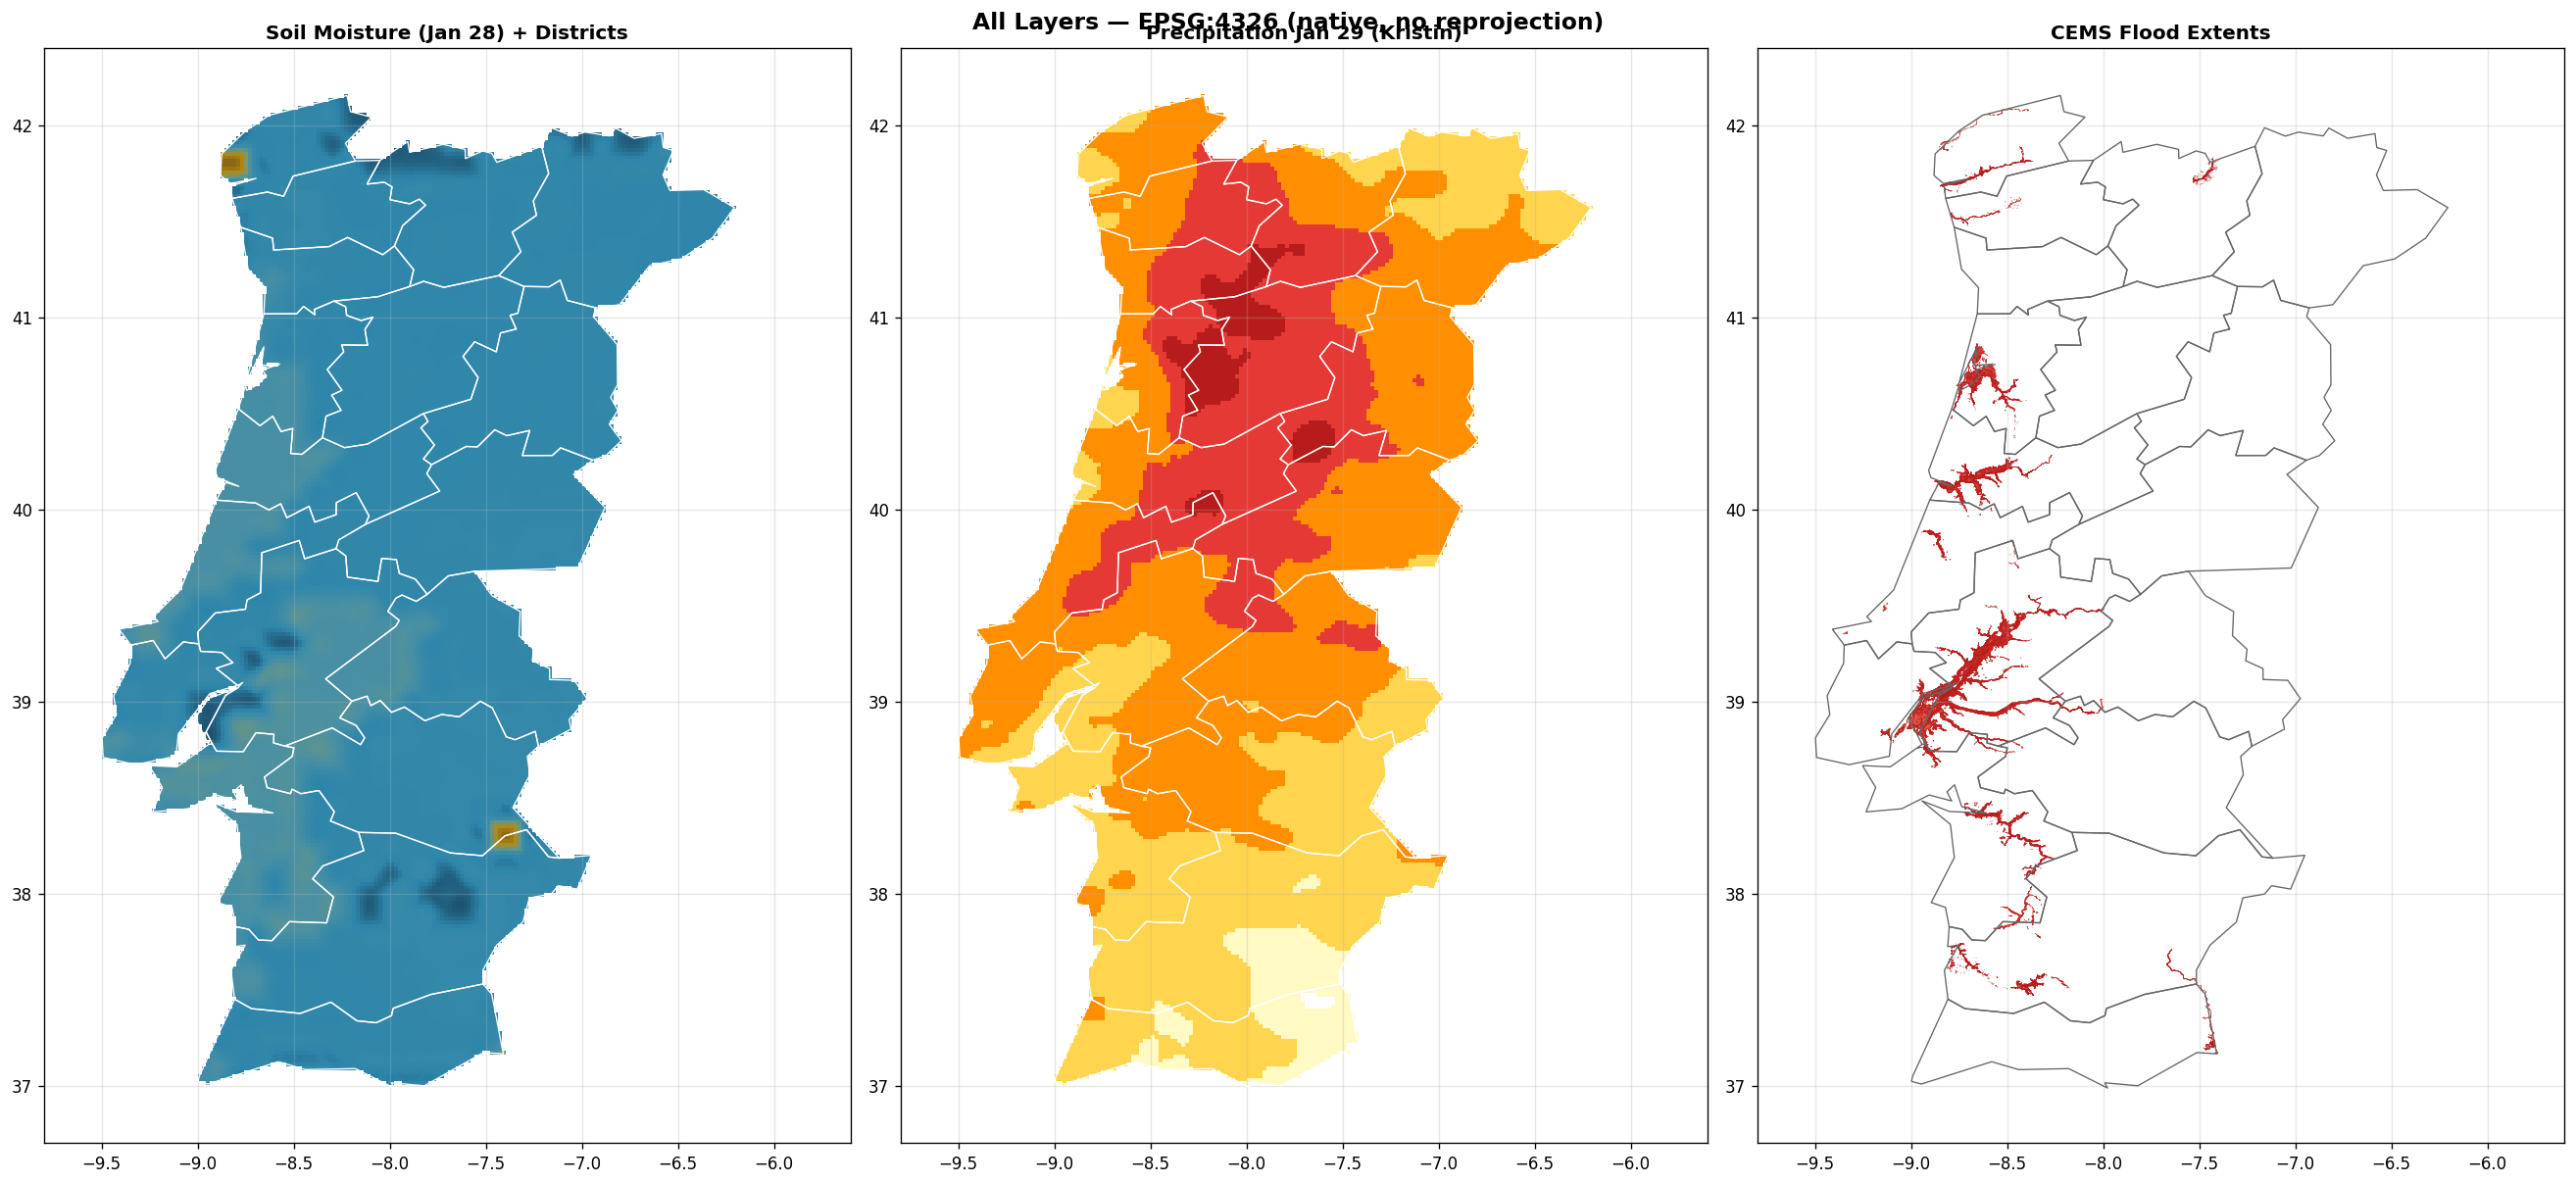

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(22, 10))

ax = axes[0]
ax.set_title('Soil Moisture (Jan 28) + Districts', fontweight='bold')
ax.imshow(np.ma.masked_invalid(sm_jan28), extent=sm_extent, origin='upper',
          cmap=SM_CMAP, vmin=0, vmax=0.55, interpolation='nearest')
districts.boundary.plot(ax=ax, color='white', linewidth=0.8)
ax.set_xlim(WEST-0.2, EAST+0.5); ax.set_ylim(SOUTH-0.2, NORTH+0.2)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.set_title('Precipitation Jan 29 (Kristin)', fontweight='bold')
ax.imshow(np.ma.masked_where(np.isnan(pr_kristin)|(pr_kristin<1), pr_kristin),
          extent=pr_extent, origin='upper', cmap=PRECIP_CMAP, norm=PRECIP_NORM, interpolation='nearest')
districts.boundary.plot(ax=ax, color='white', linewidth=0.8)
ax.set_xlim(WEST-0.2, EAST+0.5); ax.set_ylim(SOUTH-0.2, NORTH+0.2)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.set_title('CEMS Flood Extents', fontweight='bold')
districts.boundary.plot(ax=ax, color='#666', linewidth=0.8)
if all_floods.crs != districts.crs: all_floods = all_floods.to_crs(districts.crs)
all_floods.plot(ax=ax, color='#e74c3c', alpha=0.6, edgecolor='#b71c1c', linewidth=0.3)
ax.set_xlim(WEST-0.2, EAST+0.5); ax.set_ylim(SOUTH-0.2, NORTH+0.2)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

plt.suptitle('All Layers — EPSG:4326 (native, no reprojection)', fontsize=14, fontweight='bold')
plt.tight_layout()


## 7. Source Grid — where the actual data points are

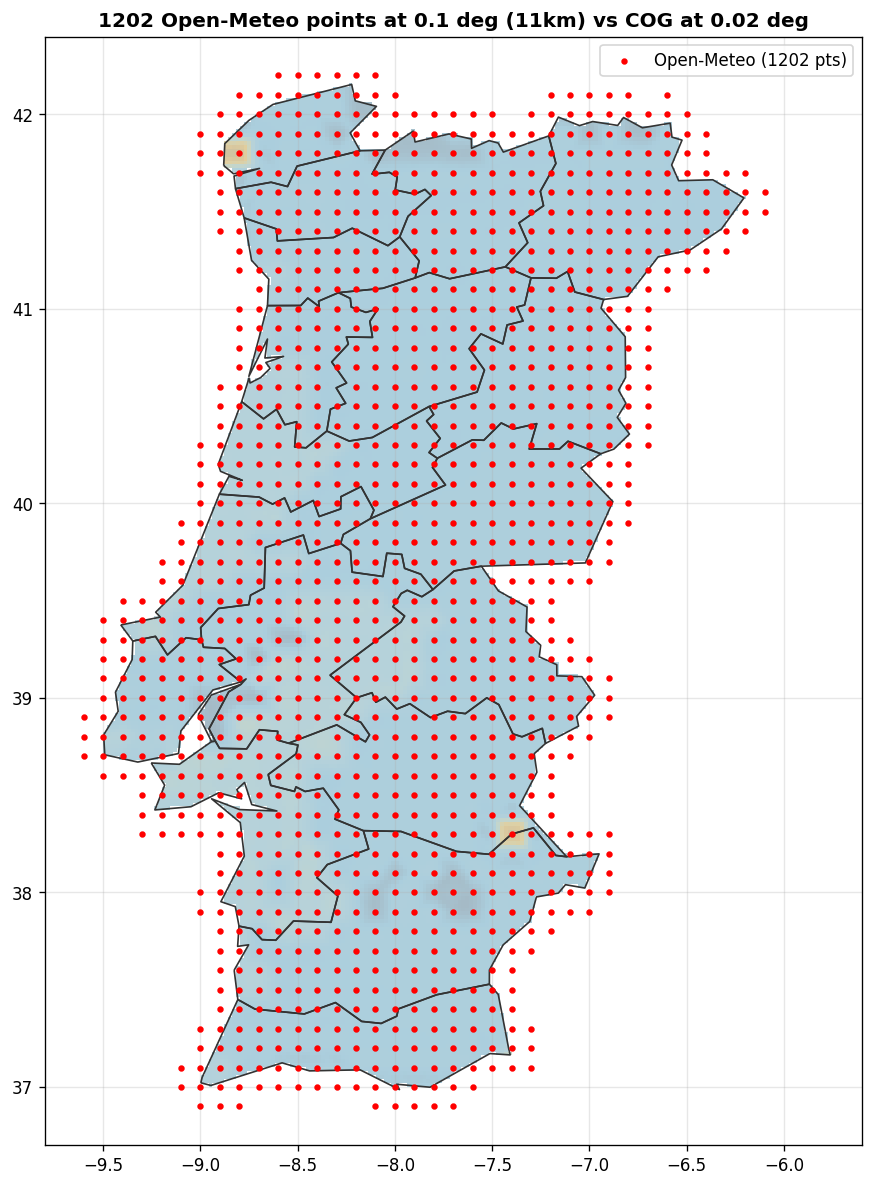

In [8]:
cache_files = sorted((DATA / 'cache' / 'soil-moisture-01').glob('*.json'))
src_lats, src_lons = [], []
for f in cache_files:
    d = json.load(open(f)); src_lats.append(d['lat']); src_lons.append(d['lon'])

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_title(f'{len(cache_files)} Open-Meteo points at 0.1 deg (11km) vs COG at 0.02 deg', fontweight='bold')
ax.imshow(np.ma.masked_invalid(sm_jan28), extent=sm_extent, origin='upper',
          cmap=SM_CMAP, vmin=0, vmax=0.55, alpha=0.4, interpolation='nearest')
districts.boundary.plot(ax=ax, color='#333', linewidth=1)
ax.scatter(src_lons, src_lats, c='red', s=8, zorder=3, label=f'Open-Meteo ({len(cache_files)} pts)')
ax.legend(fontsize=10)
ax.set_xlim(WEST-0.2, EAST+0.5); ax.set_ylim(SOUTH-0.2, NORTH+0.2)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)


## 8. Resolution — zoom to Lisbon to see pixel size

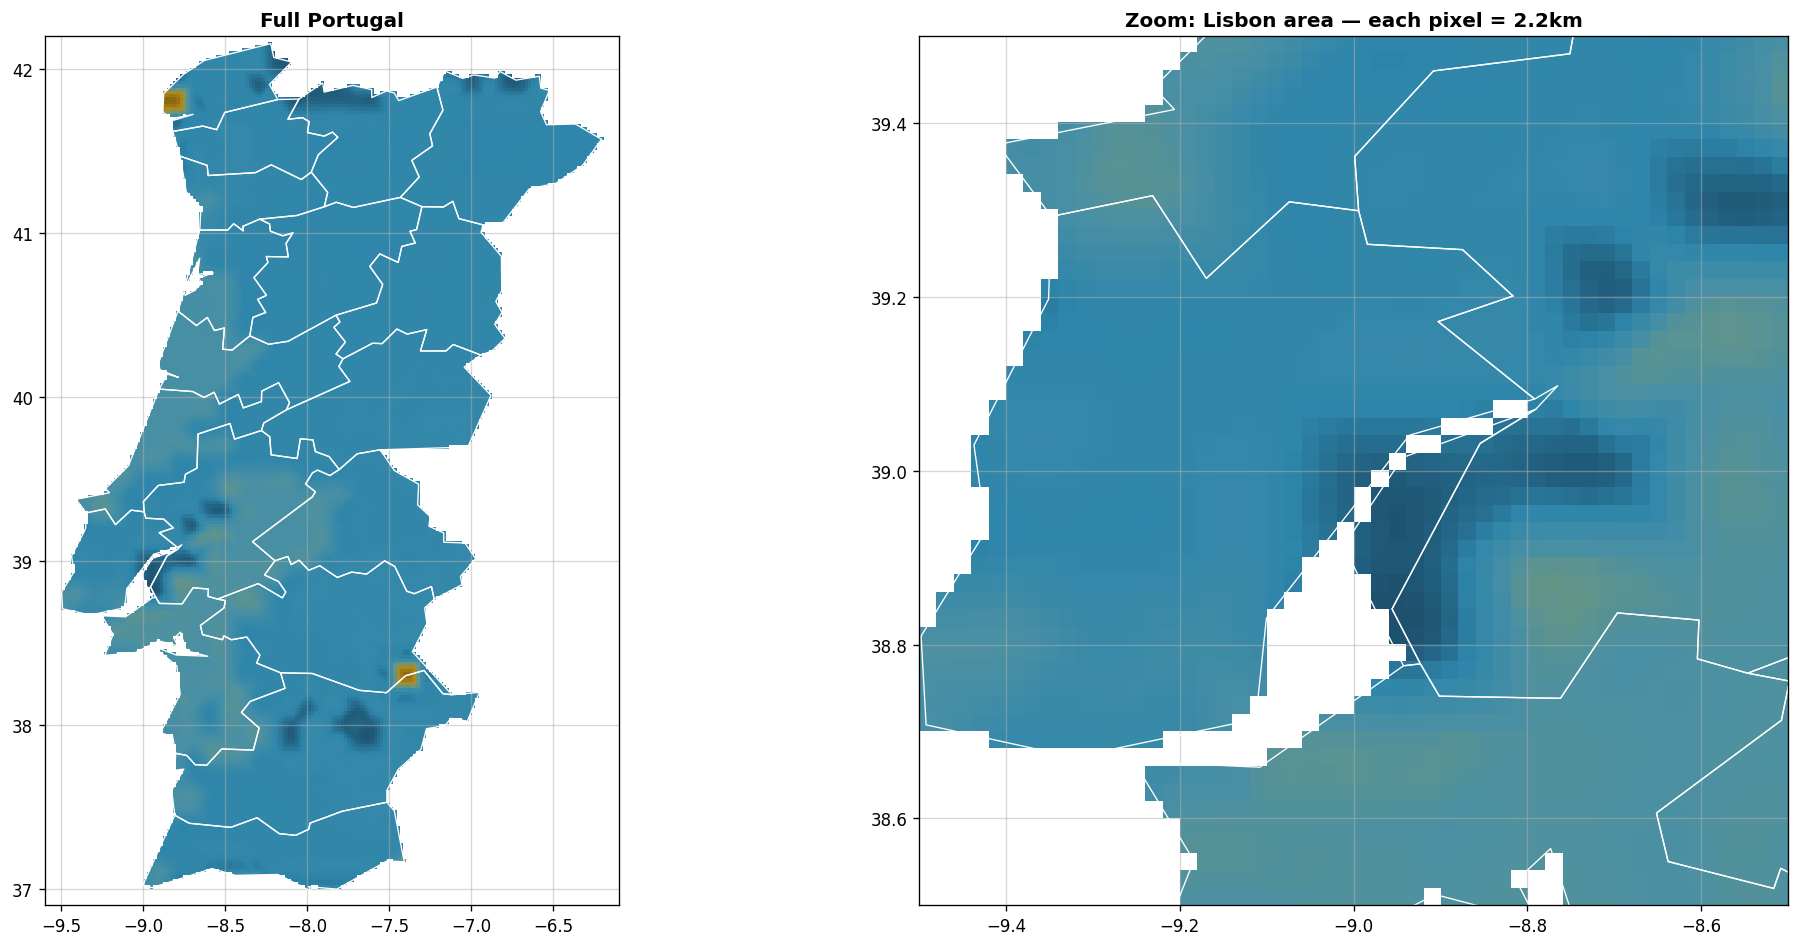

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, xlim, ylim, title in [
    (axes[0], (WEST, EAST), (SOUTH, NORTH), 'Full Portugal'),
    (axes[1], (-9.5, -8.5), (38.5, 39.5), 'Zoom: Lisbon area — each pixel = 2.2km'),
]:
    ax.set_title(title, fontweight='bold')
    ax.imshow(np.ma.masked_invalid(sm_jan28), extent=sm_extent, origin='upper',
              cmap=SM_CMAP, vmin=0, vmax=0.55, interpolation='nearest')
    districts.boundary.plot(ax=ax, color='white', linewidth=0.8)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect('equal')
    ax.grid(True, alpha=0.5)
plt.tight_layout()


## 9. Interpolation Artifacts

Magenta = pixels outside P2-P98. Cubic overshoot at coast/nodata edges.

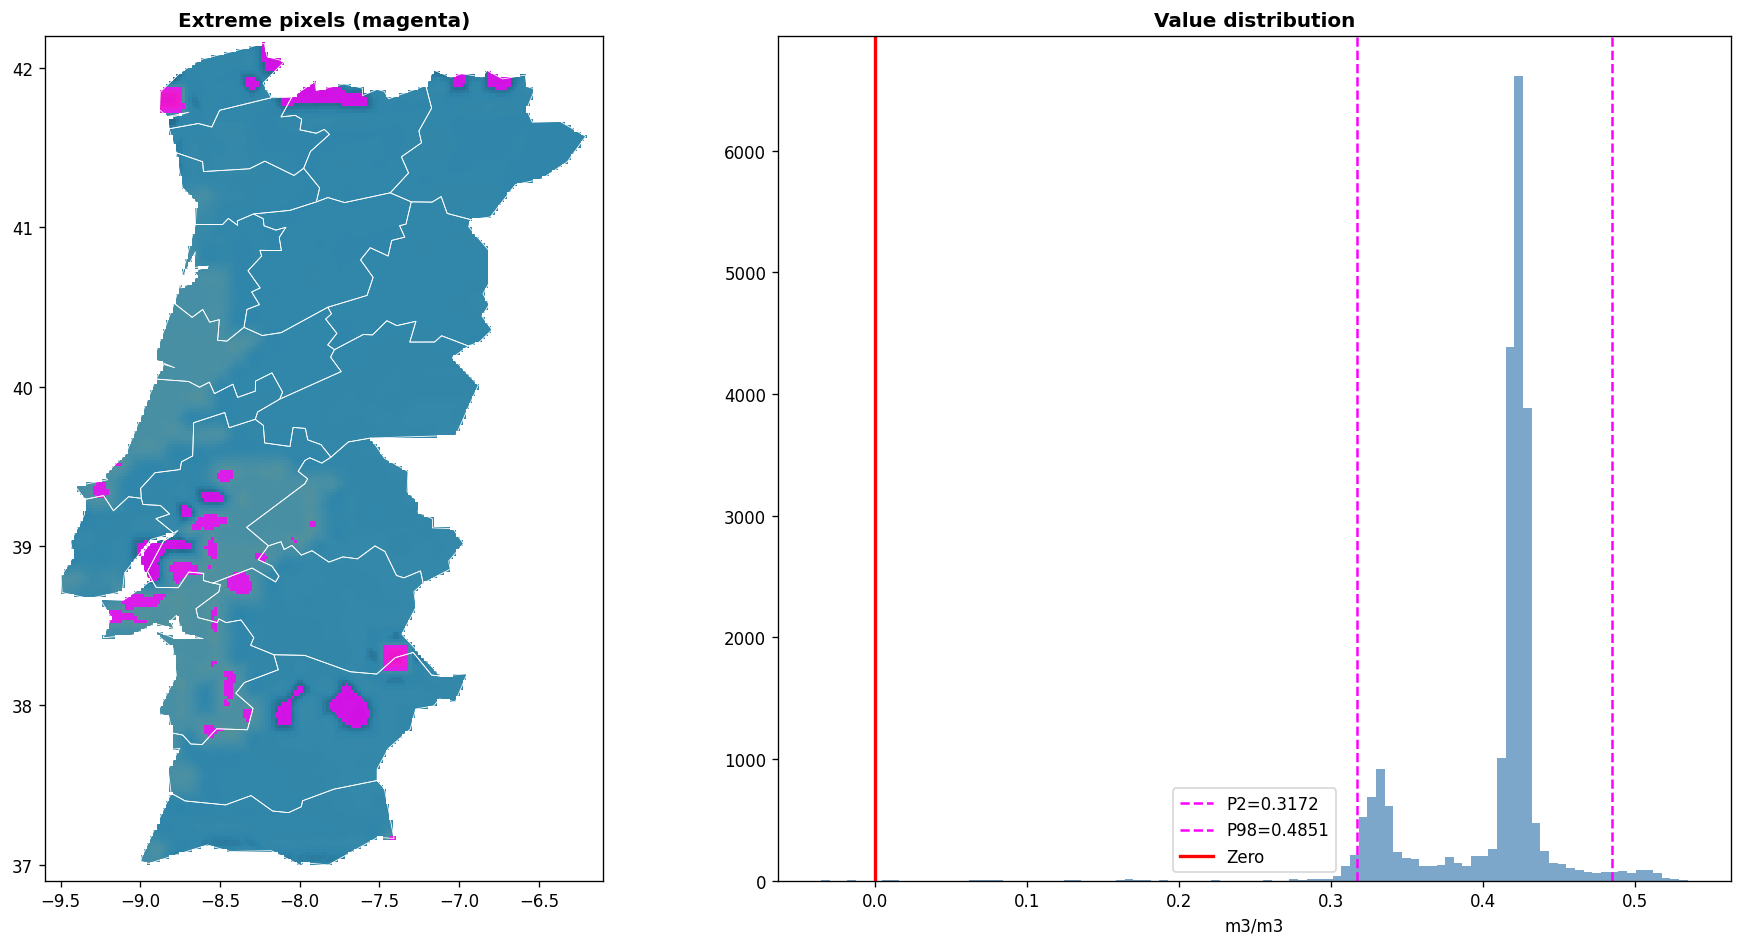

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
valid_mask = ~np.isnan(sm_jan28)
valid_vals = sm_jan28[valid_mask]
p2, p98 = np.percentile(valid_vals, [2, 98])

ax = axes[0]
ax.set_title('Extreme pixels (magenta)', fontweight='bold')
ax.imshow(np.ma.masked_invalid(sm_jan28), extent=sm_extent, origin='upper',
          cmap=SM_CMAP, vmin=0, vmax=0.55, interpolation='nearest')
ov = np.zeros((*sm_jan28.shape, 4))
ov[valid_mask & ((sm_jan28 < p2) | (sm_jan28 > p98))] = [1,0,1,0.8]
ax.imshow(ov, extent=sm_extent, origin='upper')
districts.boundary.plot(ax=ax, color='white', linewidth=0.5)
ax.set_xlim(WEST, EAST); ax.set_ylim(SOUTH, NORTH); ax.set_aspect('equal')

ax = axes[1]
ax.set_title('Value distribution', fontweight='bold')
ax.hist(valid_vals, bins=100, color='steelblue', alpha=0.7)
ax.axvline(p2, color='magenta', ls='--', label=f'P2={p2:.4f}')
ax.axvline(p98, color='magenta', ls='--', label=f'P98={p98:.4f}')
ax.axvline(0, color='red', lw=2, label='Zero'); ax.legend()
ax.set_xlabel('m3/m3')
plt.tight_layout()


## 10. Flood Extent Zoom — EMSR861 + EMSR864

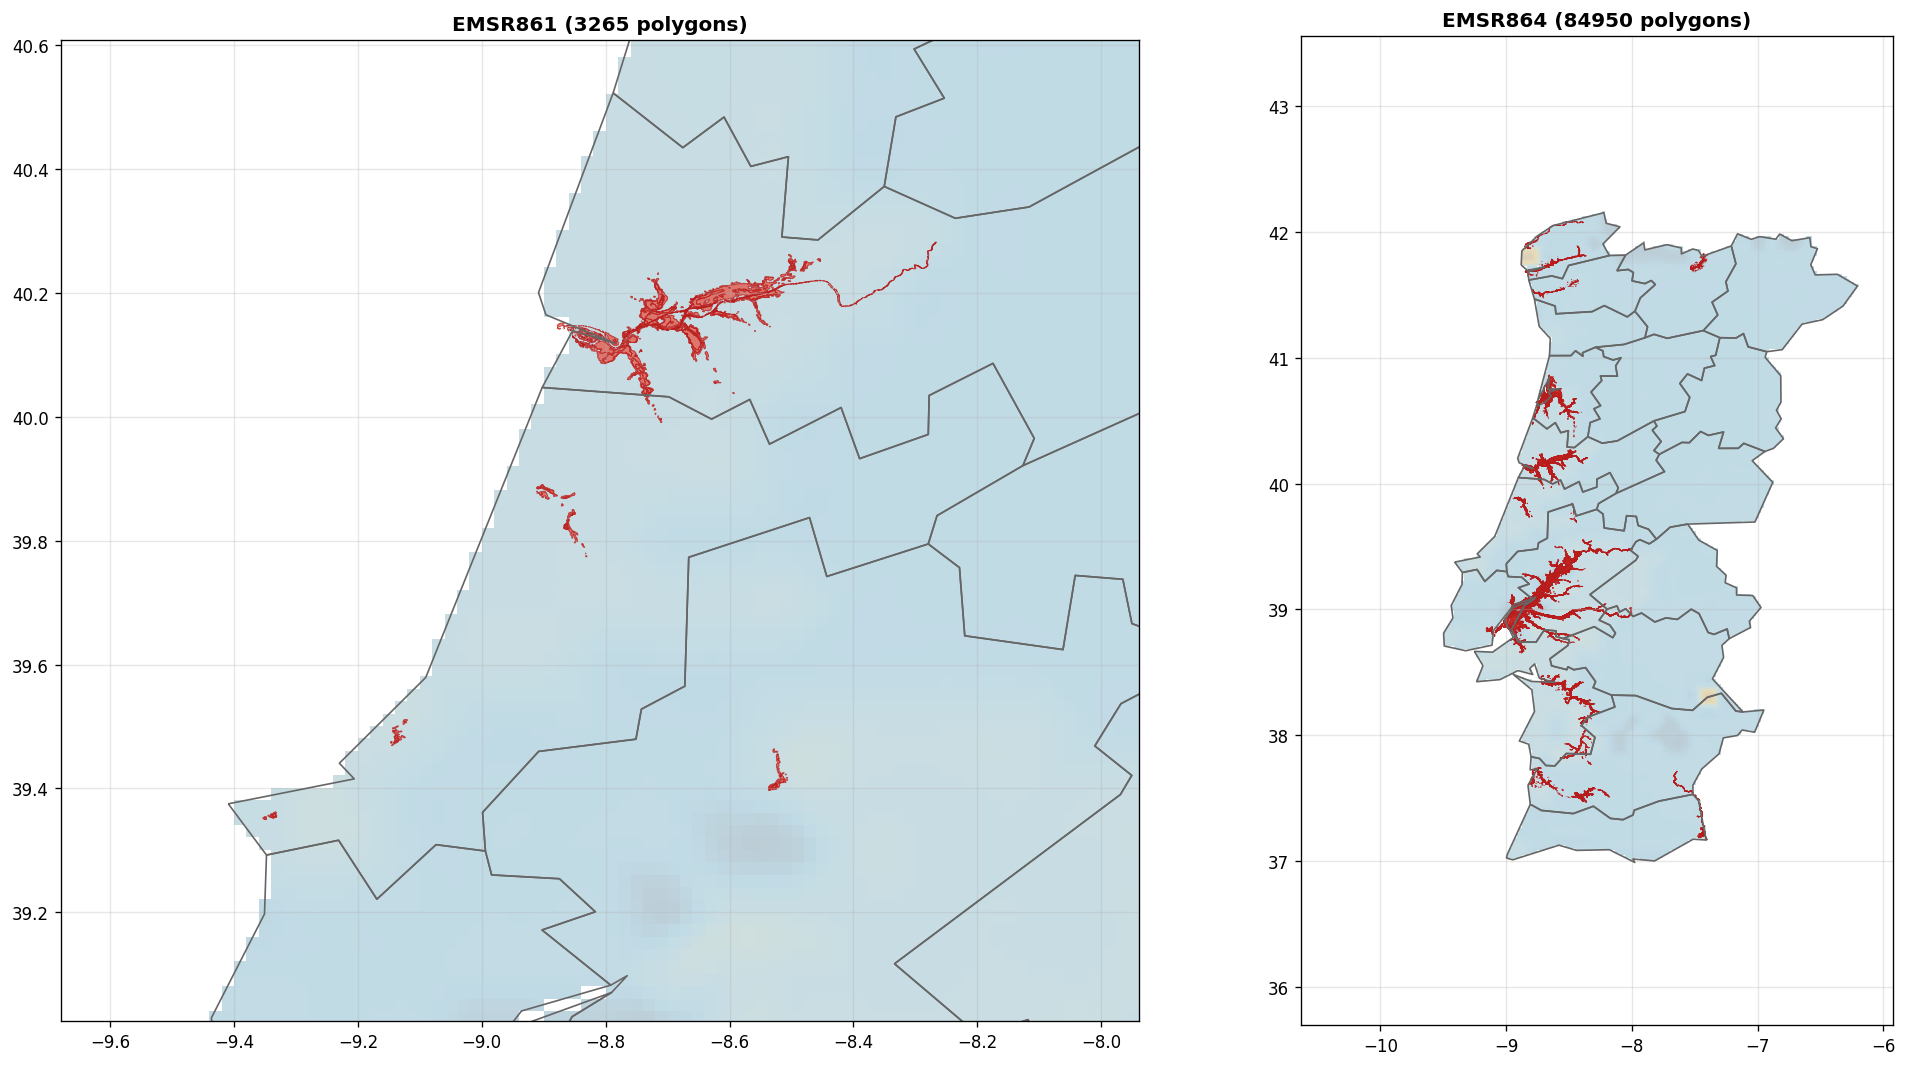

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, eid in zip(axes, ['EMSR861','EMSR864']):
    sub = all_floods[all_floods.source_dir.str.startswith(eid)]
    b = sub.total_bounds; pad = max(b[2]-b[0], b[3]-b[1]) * 0.3
    ax.set_title(f'{eid} ({len(sub)} polygons)', fontweight='bold')
    districts.boundary.plot(ax=ax, color='#666', linewidth=1)
    ax.imshow(np.ma.masked_invalid(sm_jan28), extent=sm_extent, origin='upper',
              cmap=SM_CMAP, vmin=0, vmax=0.55, alpha=0.3, interpolation='nearest')
    sub.plot(ax=ax, color='#e74c3c', alpha=0.7, edgecolor='#b71c1c', linewidth=0.5)
    ax.set_xlim(b[0]-pad, b[2]+pad); ax.set_ylim(b[1]-pad, b[3]+pad)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.tight_layout()


## 11. River Basins

,river,name_en,name_pt,type,transboundary,parent,geometry
0,Guadiana,Guadiana,Guadiana,major,True,NaN,"POLYGON ((-7.27491 37.96885, -7.26546 37.97828..."
1,Algarve,Algarve Coast,Ribeiras do Algarve,coastal,False,NaN,"POLYGON ((-8.07083 37.29167, -8.09583 37.32917..."
2,Sado,Sado,Sado,major,False,NaN,"MULTIPOLYGON (((-8.70833 37.79167, -8.68333 37..."
3,Tejo,Tagus,Tejo,major,True,NaN,"POLYGON ((-8.33333 39.48333, -8.32411 39.49512..."
4,Zêzere,Zêzere,Zêzere,tributary,False,Tejo,"POLYGON ((-7.72083 39.47083, -7.70612 39.46307..."


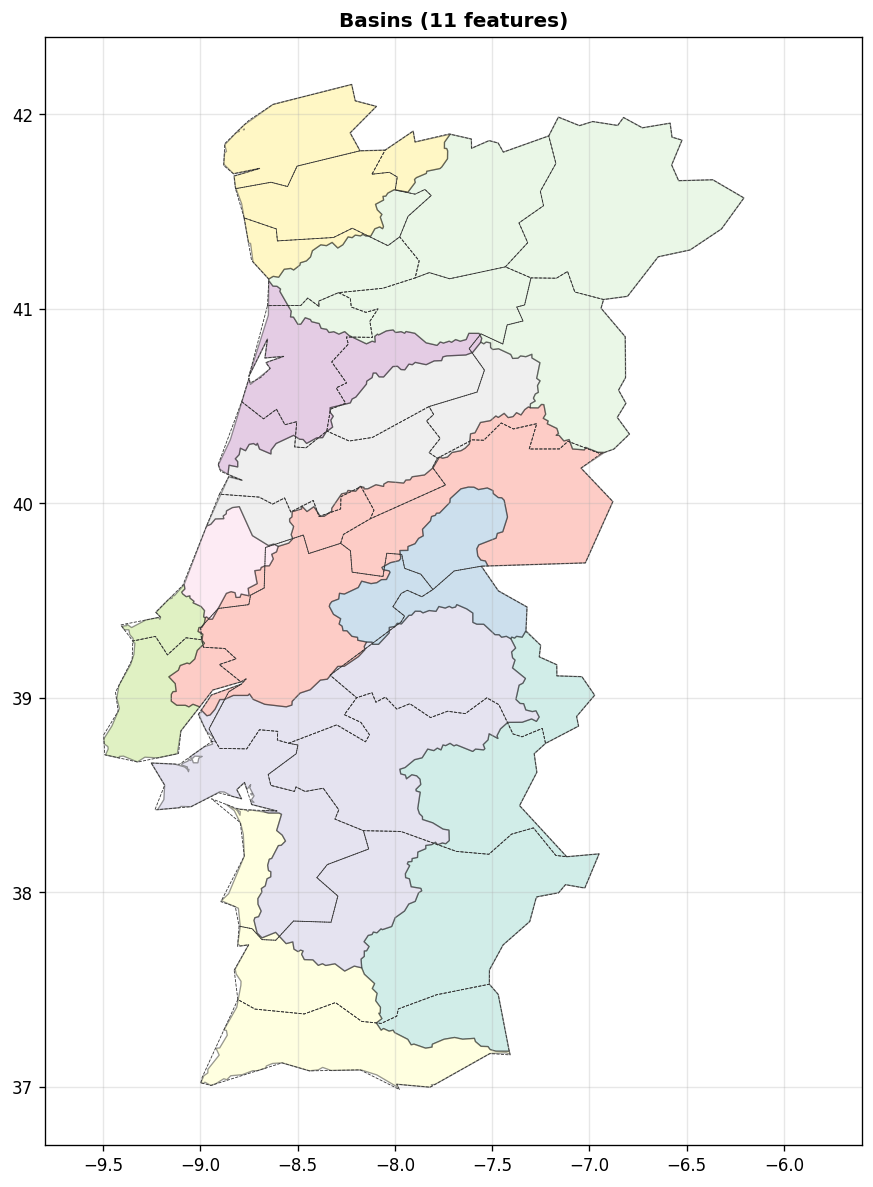

In [12]:
if basins is not None:
    fig, ax = plt.subplots(figsize=(10, 12))
    ax.set_title(f'Basins ({len(basins)} features)', fontweight='bold')
    basins.plot(ax=ax, alpha=0.4, edgecolor='black', linewidth=0.8, cmap='Set3')
    districts.boundary.plot(ax=ax, color='#333', linewidth=0.5, linestyle='--')
    ax.set_xlim(WEST-0.2, EAST+0.5); ax.set_ylim(SOUTH-0.2, NORTH+0.2)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    display(basins.head())
else:
    print('No basins file')


## 12. Projection Offset

COGs = EPSG:4326 (even lat spacing). MapLibre = EPSG:3857 (Mercator Y). Result: **7.3km shift**.

In [13]:
def lat_to_merc(lat):
    return 6378137 * np.log(np.tan(np.pi/4 + np.radians(lat)/2))

s, n = 36.9, 42.2
ms, mn = lat_to_merc(s), lat_to_merc(n)
actual = lat_to_merc((s+n)/2)
linear = (ms + mn) / 2
print(f'Offset at center of Portugal: {abs(actual - linear)/1000:.1f} km')
print(f'Fix: reproject to 3857 before serving, or use titiler.')


Offset at center of Portugal: 7.3 km
Fix: reproject to 3857 before serving, or use titiler.


## Summary

| # | Issue | Severity | Fix |
|---|-------|----------|-----|
| 1 | **Projection offset 7.3km** | High | Reproject PNGs to 3857 or use titiler |
| 2 | **Interpolation artifacts** | Medium | Clamp P2/P98 + gaussian blur |
| 3 | **11km source resolution** | Inherent | Accept as weather-map or switch source |
| 4 | **Flood extents not rendering** | High | Frontend bug, data is fine |
| 5 | **Coastline mask jagged** | Low | Re-rasterize mask in target CRS |
